# CLIP 图文检索 Demo

先用 CLIP 编码 1000 张图片并缓存向量；输入英文文本后，计算文本向量与图片向量的 cosine similarity，展示最相近的 5 张图片。这里不训练模型，也不使用 softmax。

流程：准备图片 → 加载预训练 CLIP → 编码并缓存图片 → 输入文本并检索。首次运行会下载约 94 MB 的 Imagenette 图片和 CLIP 模型。

## 1. 准备数据与目录

从 Imagenette 训练集的 10 个类别中，每类按固定随机种子抽取 100 张。图片、压缩包和特征缓存都留在项目目录中，方便后续运行复用。

In [1]:
import hashlib
import json
import os
import random
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from tqdm.auto import tqdm

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
IMAGE_DIR = DATA_DIR / "imagenette2-160"
CACHE_DIR = ROOT / "cache"
ARCHIVE_PATH = DATA_DIR / "imagenette2-160.tgz"
IMAGE_LIST_PATH = CACHE_DIR / "image_manifest.json"
FEATURE_CACHE_PATH = CACHE_DIR / "image_features.npz"
DATA_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz"
MODEL_ID = "openai/clip-vit-base-patch32"
LOCAL_MODEL_DIR = DATA_DIR / "clip-vit-base-patch32"
MODEL_PATH = os.environ.get("CLIP_MODEL_PATH", str(LOCAL_MODEL_DIR if (LOCAL_MODEL_DIR / 'config.json').exists() else MODEL_ID))
SEED = 42
IMAGES_PER_CLASS = 100
BATCH_SIZE = 32

DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

if not IMAGE_DIR.exists():
    if not ARCHIVE_PATH.exists():
        print(f"下载 Imagenette：{DATA_URL}")
        with urllib.request.urlopen(DATA_URL, timeout=60) as response, ARCHIVE_PATH.open("wb") as target:
            total = int(response.headers.get("Content-Length", 0))
            with tqdm(total=total, unit="B", unit_scale=True, desc="下载图片集") as progress:
                while chunk := response.read(1024 * 1024):
                    target.write(chunk)
                    progress.update(len(chunk))
    print("解压图片集…")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
        archive.extractall(DATA_DIR, filter="data")

train_dir = IMAGE_DIR / "train"
if not train_dir.is_dir():
    raise FileNotFoundError(f"没有找到 Imagenette 训练目录：{train_dir}")

rng = random.Random(SEED)
image_paths = []
for class_dir in sorted(path for path in train_dir.iterdir() if path.is_dir()):
    candidates = sorted(path for path in class_dir.rglob("*") if path.suffix.lower() in {".jpg", ".jpeg", ".png"})
    if len(candidates) < IMAGES_PER_CLASS:
        raise ValueError(f"类别 {class_dir.name} 只有 {len(candidates)} 张图片")
    image_paths.extend(rng.sample(candidates, IMAGES_PER_CLASS))

image_paths = sorted(image_paths)
if len(image_paths) != 1000:
    raise ValueError(f"预期 1000 张图片，实际找到 {len(image_paths)} 张")

image_manifest = [path.relative_to(ROOT).as_posix() for path in image_paths]
IMAGE_LIST_PATH.write_text(json.dumps(image_manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"已准备 {len(image_paths)} 张图片，来自 {len(set(path.parent.name for path in image_paths))} 个类别。")
print(f"运行设备：{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

已准备 1000 张图片，来自 10 个类别。
运行设备：NVIDIA GeForce RTX 5070 Ti


/home/wuqiang/projects/CLIP-Retrieval-Demo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


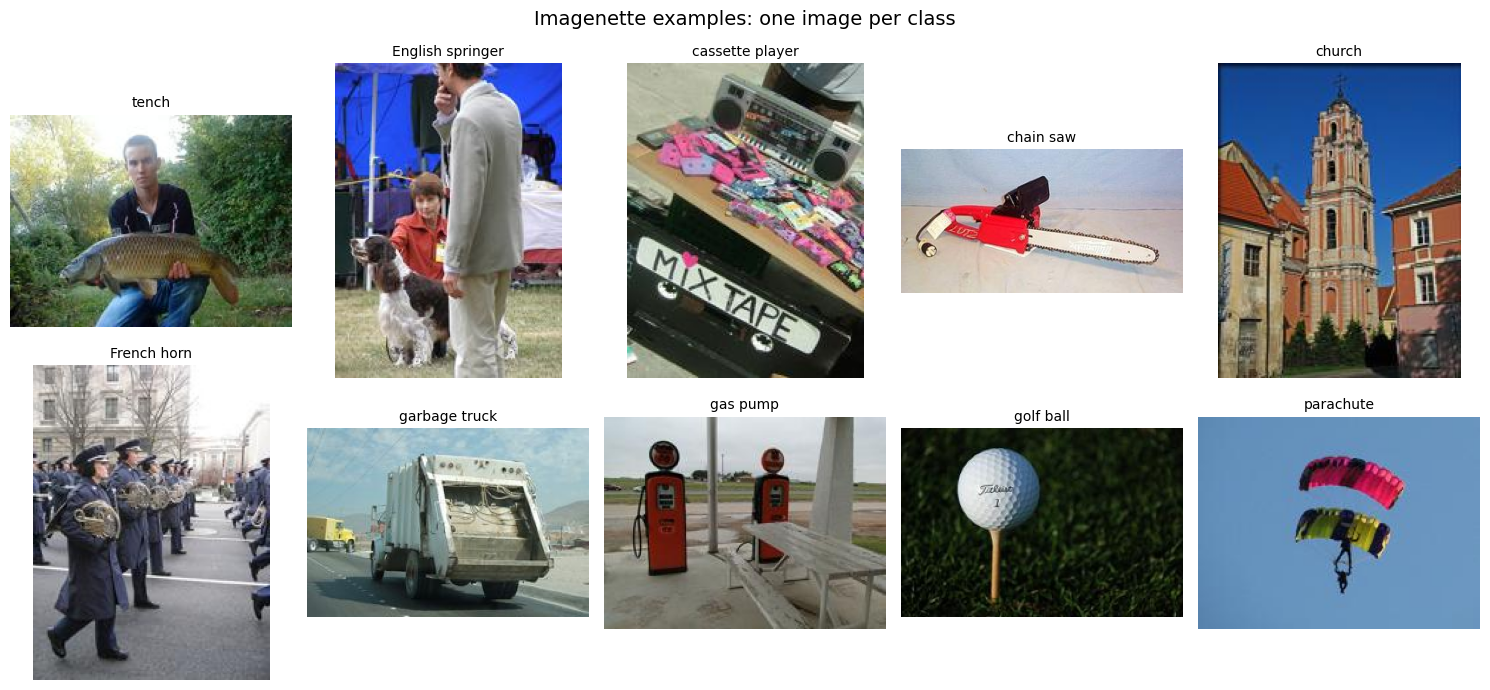

Displayed one example from each of 10 classes.


In [2]:
import matplotlib.pyplot as plt
from PIL import Image

class_names = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute",
}

# Reuse the image list prepared in the previous cell and keep one image per class.
examples_by_class = {}
for image_path in image_paths:
    examples_by_class.setdefault(image_path.parent.name, image_path)

if len(examples_by_class) != 10:
    raise ValueError(f"Expected 10 classes, found {len(examples_by_class)}")

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
for axis, (class_id, image_path) in zip(axes.flat, sorted(examples_by_class.items())):
    with Image.open(image_path) as image:
        axis.imshow(image.convert("RGB"))
    axis.set_title(class_names.get(class_id, class_id), fontsize=10)
    axis.axis("off")

fig.suptitle("Imagenette examples: one image per class", fontsize=14)
fig.tight_layout()
plt.show()
print(f"Displayed one example from each of {len(examples_by_class)} classes.")


## 2. 加载 CLIP 图文编码器

使用与 CLIP ViT-B/32 配套的 Processor 做图像预处理和文本分词。WSL 能访问 Hugging Face 时会自动下载模型；也可以在启动 Jupyter 前设置 CLIP_MODEL_PATH 指向已下载的模型目录。

In [3]:
from transformers import AutoProcessor, CLIPModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"加载模型 {MODEL_PATH} 到 {device}…")
try:
    processor = AutoProcessor.from_pretrained(MODEL_PATH)
    model = CLIPModel.from_pretrained(MODEL_PATH).to(device).eval()
except OSError as error:
    raise RuntimeError(
        "无法加载 CLIP 模型。请检查 Hugging Face 网络，或设置 CLIP_MODEL_PATH 指向已下载的模型目录。"
    ) from error

print(f"模型已就绪；特征维度：{model.config.projection_dim}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


加载模型 /home/wuqiang/projects/CLIP-Retrieval-Demo/data/clip-vit-base-patch32 到 cuda…
模型已就绪；特征维度：512


## 3. 批量编码并缓存图片向量

模型将图片映射到 512 维空间。把每个向量除以它的 L2 范数后，向量点积就等于 cosine similarity。缓存同时记录模型标识和图片文件信息；它们改变时会重新编码。

In [4]:
def normalize(features: torch.Tensor) -> torch.Tensor:
    return features / features.norm(dim=-1, keepdim=True).clamp_min(1e-12)

file_facts = []
for path in image_paths:
    stat = path.stat()
    file_facts.append((path.relative_to(ROOT).as_posix(), stat.st_size, stat.st_mtime_ns))
cache_signature = hashlib.sha256(
    json.dumps({"model": str(MODEL_PATH), "images": file_facts}, sort_keys=True).encode("utf-8")
).hexdigest()

if FEATURE_CACHE_PATH.exists():
    with np.load(FEATURE_CACHE_PATH, allow_pickle=False) as saved:
        cache_is_valid = str(saved["signature"].item()) == cache_signature
        if cache_is_valid:
            image_features = torch.from_numpy(saved["features"].copy()).to(device)
            cached_paths = saved["paths"].tolist()
            cache_is_valid = cached_paths == image_manifest
else:
    cache_is_valid = False

if cache_is_valid:
    print(f"已加载缓存：{FEATURE_CACHE_PATH}")
else:
    batches = []
    for start in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="编码图片"):
        batch_paths = image_paths[start : start + BATCH_SIZE]
        images = []
        for path in batch_paths:
            with Image.open(path) as image:
                images.append(image.convert("RGB"))
        inputs = processor(images=images, return_tensors="pt")
        inputs = {name: tensor.to(device) for name, tensor in inputs.items()}
        with torch.inference_mode():
            features = model.get_image_features(**inputs)
        if hasattr(features, "pooler_output"):
            features = features.pooler_output
        elif isinstance(features, tuple):
            features = features[0]
        batches.append(normalize(features).float().cpu())

    image_features = torch.cat(batches, dim=0).to(device)
    np.savez_compressed(
        FEATURE_CACHE_PATH,
        features=image_features.cpu().numpy(),
        paths=np.asarray(image_manifest),
        signature=np.asarray(cache_signature),
    )
    print(f"图片向量已缓存到 {FEATURE_CACHE_PATH}")

assert image_features.shape == (1000, model.config.projection_dim), image_features.shape
assert torch.isfinite(image_features).all()
assert torch.allclose(image_features.norm(dim=1), torch.ones(1000, device=device), atol=1e-4)
print(f"图片特征矩阵：{tuple(image_features.shape)}；每行都是单位向量。")

已加载缓存：/home/wuqiang/projects/CLIP-Retrieval-Demo/cache/image_features.npz
图片特征矩阵：(1000, 512)；每行都是单位向量。


## 4. 输入文本并查看 Top-5

Query 使用英文，因为标准 CLIP 主要针对英文图文训练。修改 query 变量后重新运行本单元格即可；空文本会给出提示。

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


1. data/imagenette2-160/train/n02102040/n02102040_1103.JPEG  cosine similarity = 0.2821
2. data/imagenette2-160/train/n02102040/n02102040_2565.JPEG  cosine similarity = 0.2775
3. data/imagenette2-160/train/n02102040/n02102040_6124.JPEG  cosine similarity = 0.2759
4. data/imagenette2-160/train/n02102040/n02102040_4779.JPEG  cosine similarity = 0.2754
5. data/imagenette2-160/train/n02102040/n02102040_2039.JPEG  cosine similarity = 0.2730


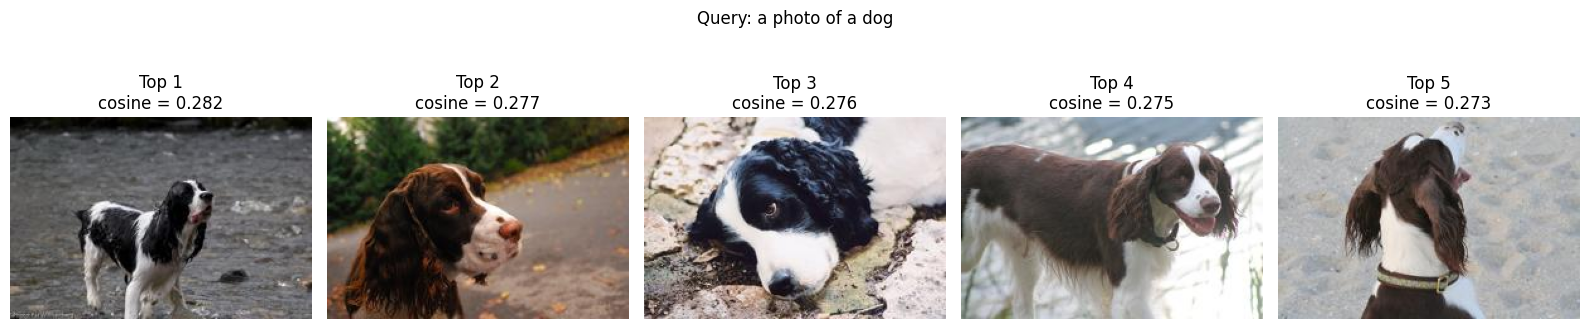

In [5]:
def search(query: str, top_k: int = 5) -> list[dict]:
    query = query.strip()
    if not query:
        raise ValueError("Query 不能为空，请输入一段英文描述。")
    if not 1 <= top_k <= len(image_paths):
        raise ValueError(f"top_k 必须在 1 到 {len(image_paths)} 之间。")

    inputs = processor(text=[query], return_tensors="pt", padding=True, truncation=True)
    inputs = {name: tensor.to(device) for name, tensor in inputs.items()}
    with torch.inference_mode():
        text_features = model.get_text_features(**inputs)
    if hasattr(text_features, "pooler_output"):
        text_features = text_features.pooler_output
    elif isinstance(text_features, tuple):
        text_features = text_features[0]
    text_features = normalize(text_features)
    global _last_text_features
    _last_text_features = text_features.detach()

    # 两边都做 L2 归一化后，矩阵点积就是 cosine similarity。
    similarities = (image_features @ text_features.T).squeeze(1)
    scores, indices = torch.topk(similarities, k=top_k)
    return [
        {"path": image_paths[index], "score": float(score)}
        for score, index in zip(scores.cpu().tolist(), indices.cpu().tolist())
    ]


def show_results(query: str, results: list[dict]) -> None:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, len(results), figsize=(16, 4))
    if len(results) == 1:
        axes = [axes]
    for rank, (axis, result) in enumerate(zip(axes, results), start=1):
        with Image.open(result["path"]) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"Top {rank}\ncosine = {result['score']:.3f}")
        axis.axis("off")
    fig.suptitle(f"Query: {query}")
    fig.tight_layout()
    plt.show()


query = "a photo of a dog"  # 也可以试试：a church、a parachute
if query.strip():
    results = search(query, top_k=5)
    for rank, result in enumerate(results, start=1):
        print(f"{rank}. {result['path'].relative_to(ROOT)}  cosine similarity = {result['score']:.4f}")
    show_results(query, results)
else:
    print("Query 不能为空，请设置 query 后重试。")

## 5. 检查相似度与缓存

下面直接计算 cosine similarity，与归一化向量的点积对照。再执行一次图片编码单元格，应显示加载缓存；更改 Query 只会重新计算文本向量与相似度。

In [7]:
if query.strip():
    top_result = results[0]
    image_index = image_paths.index(top_result["path"])
    text_vector = _last_text_features
    direct_cosine = torch.nn.functional.cosine_similarity(
        image_features[image_index].unsqueeze(0), text_vector
    ).item()
    dot_product = (image_features[image_index] @ text_vector.squeeze(0)).item()
    print(f"直接计算的 cosine similarity：{direct_cosine:.6f}")
    print(f"归一化向量的点积：         {dot_product:.6f}")
    assert abs(direct_cosine - dot_product) < 1e-5
    assert abs(dot_product - top_result["score"]) < 1e-5
    print("一致：点积结果就是 cosine similarity。")

直接计算的 cosine similarity：0.282055
归一化向量的点积：         0.282055
一致：点积结果就是 cosine similarity。
